In [13]:
import torch
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from pathlib import Path

from going_modular.going_modular import utils, engine, data_setup, download_data

## Device agnostic code

In [14]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## Download data

In [6]:
## As I have already downloaded data, I am not gonna download it
## but you can download it using the download_data() if you haven't downloaded it yet

## Creating datasets and dataloaders

In [16]:
## Dataset directory

dataset_dir = Path('datasets/pizza_steak_sushi')

train_dir = dataset_dir / 'train'
test_dir = dataset_dir / 'test'


## Create transform

IMG_SIZE = 224

manual_transform = transforms.Compose([

    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

## create dataset

BATCH_SIZE = 32
NUM_WORKERS = 0

train_dataloader, test_dataloader, classes = data_setup.create_dataloaders(train_dir=train_dir,
                                                                           test_dir=test_dir,
                                                                           transform=manual_transform,
                                                                           batch_size=BATCH_SIZE,
                                                                           num_workers=NUM_WORKERS)

train_dataloader, test_dataloader, classes

(<torch.utils.data.dataloader.DataLoader at 0x1645440b810>,
 ['pizza', 'steak', 'sushi'])

## Visualize a single image

torch.Size([3, 224, 224]) tensor(1)


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

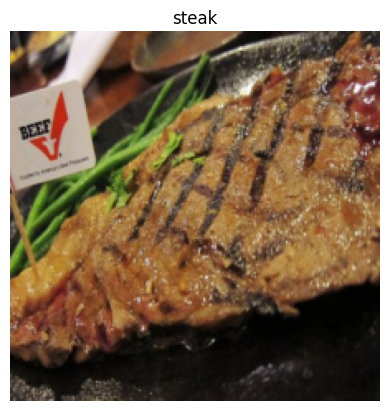

In [32]:
images, labels = next(iter(train_dataloader))

image = images[0]
label = labels[0]

print(image.shape, label)

plt.title(label=classes[label])
plt.imshow(image.permute(1, 2, 0))
plt.axis(False)